In [ ]:
## End to End Toy Project


# Steps:
# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the Values
# 3. Train Test Split
# 4. Train the Model
# 5. Evaluate the Model/ model selection
# 6. Deploy the Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df=pd.read_csv("dataset\placement.csv")

In [9]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.2 KB


In [11]:
df.describe()

,Unnamed: 0,cgpa,iq,placement
count,100.000000,100.000000,100.000000,100.000000
mean,49.500000,5.991000,123.580000,0.500000
std,29.011492,1.143634,39.944198,0.502519
min,0.000000,3.300000,37.000000,0.000000
25%,24.750000,5.075000,101.500000,0.000000
50%,49.500000,6.000000,127.500000,0.500000
75%,74.250000,6.900000,149.000000,1.000000
max,99.000000,8.500000,233.000000,1.000000


## Data Preprocessing


In [12]:
# we don't require the unnamed column

df=df.iloc[:,1:]

In [13]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


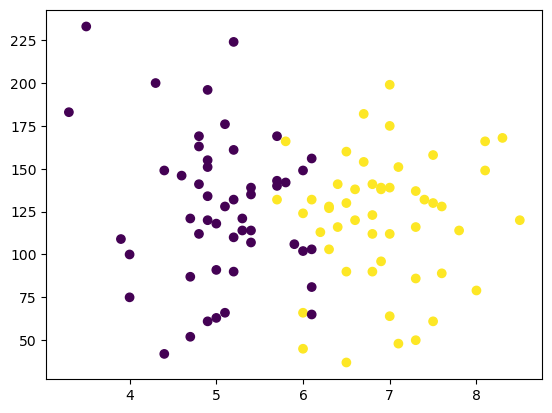

In [14]:
plt.scatter(df["cgpa"],df["iq"],c=df["placement"])

In [15]:
x=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [6]:
!pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.9 MB 2.4 MB/s eta 0:00:04
   --- ------------------------------------ 0.8/8.9 MB 1.8 MB/s eta 0:00:05
   ----- ---------------------------------- 1.3/8.9 MB 2.0 MB/s eta 0:00:04
   -------- ------------------------------- 1.8/8.9 MB 2.2 MB/s eta 0:00:04
   --------- ------------------------------ 2.1/8.9 MB 2.2 MB/s eta 0:00:04
   ------------ --------------------------- 2.9/8.9 MB 2.4 MB/s eta 0:00:03
   --------------- ------------------------ 3.4/8.9 MB 2.4 MB/s eta 0:00:03
   ----------------- ---------------------- 3.9/8.9 MB 2.4 MB/s eta 0:00:03
   --------------------- ------------------ 4.7/8.9 MB 2.5 MB/s eta 0:00:02
   ----------------------- ---------------- 5.2/8.9 MB 2.7 MB/s eta 0:00:02
   --------------------------- --------

In [19]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [7]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler=StandardScaler()

In [ ]:
x_train=scaler.fit_transform(x_train)

In [21]:
x_test=scaler.transform(x_test)

In [22]:
from sklearn.linear_model import LogisticRegression

In [23]:
clf=LogisticRegression()

In [24]:
#model training
clf.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [30]:
## Evaluate the model

y_pred=clf.predict(x_test)

In [26]:
y_test

83    1
53    1
70    1
45    1
44    1
39    0
22    0
80    0
10    1
0     1
18    0
30    1
73    0
33    0
90    1
4     0
76    0
77    1
12    0
31    0
Name: placement, dtype: int64

In [31]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
accuracy_score(y_test,y_pred)

0.85

In [35]:
!pip install mlxtend

INFO: pip is looking at multiple versions of mlxtend to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.4 MB 1.9 MB/s eta 0:00:01
   ------------------------------- -------- 1.0/1.4 MB 2.2 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 2.4 MB/s  0:00:00


<Axes: >

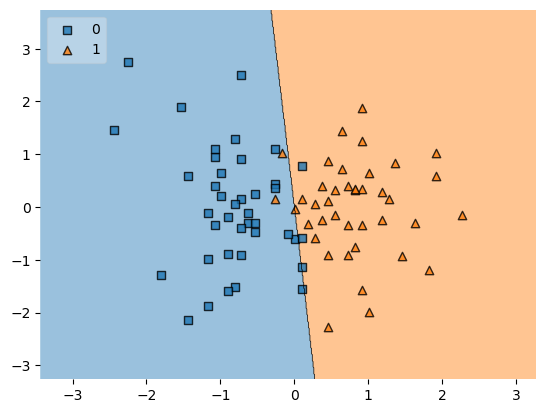

In [36]:
## Decision Boundary
from mlxtend.plotting import plot_decision_regions  

plot_decision_regions(x_train, y_train.values, clf=clf, legend=2)

In [37]:
import pickle

In [38]:
pickle.dump(clf,open("model.pkl","wb"))